# Deep Learning Models

Use this notebook to prototype neural network approaches for uplift modeling and individualized treatment effect estimation.

In [1]:
import torch
import torch.nn as nn
import math
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ATARNet (Attention TARNet) 

This notebook implements a Transformer-based TARNet type of model in PyTorch to estimate heterogeneous treatment effects using the Hillstrom dataset.

The model predicts the probability that a customer visits **with** and **without** receiving an email. The difference between these two probabilities represents the estimated individual treatment effect (uplift).

The only structural change compared with the traditional TARNet model is replacing the shared MLP representation network with a Transformer-based self-attention encoder. The motivation behind this modification is that self-attention allows the model to learn interactions between a customer's features before constructing a shared representation. Instead of compressing the input directly through a sequence of fully connected layers, the Transformer first builds contextualized feature representations by allowing each feature to attend to the others. We hypothesize that this richer representation can improve the estimation of individual treatment effects by capturing more complex relationships among customer characteristics.

In addition, the reason why we are trying to use NN for tabular challenges is that we found evidence that NN can outperform usual tree based models (Revisiting Deep Learning Models for Tabular Data). It still does not outperform by much to make worth the effort, but this might be an interesting avenue to dedicate some time to do research on. Also, we want to break with the monolpoly of tree based models for a moment and try something more exciting.

# 1. Define the Neural Network Architecture

This section defines all the PyTorch classes required to build the ATARNet model. 

The architecture converts customer features into feature embeddings, learns interactions between those features using self-attention, and estimates the potential outcomes under both treatment and control.


## Model Components

- **FeatureTokenizer**
  - Converts numerical and categorical features into a common embedding space.
  - An important distinction is that we dont need to transform the categorical variables into dummy ones anymore as we did with the Causation Tree model. We think that by doing this we can retain more information about the relationship between different groups of categorical variables such as channel vs zip_code.

- **SelfAttentionHead**
  - Learns relationships between customer features.

- **MultiHeadSelfAttention**
  - Combines several attention heads to capture different feature interactions.

- **Transformer**
  - Applies self-attention, residual connections, layer normalization, and a feed-forward network.

- **OutcomeHead**
  - Predicts the probability of the outcome under one treatment condition.

- **ATARNet**
  - Combines all previous components into a complete uplift model.

- **Loss**
  - Computes the factual loss using only the observed treatment assignment.

## Model Architecture

```text
Raw Features
      │
      ▼
Feature Tokenizer
      │
      ▼
Transformer
      │
      ▼
Mean Pooling
      │
      ▼
Shared Customer Representation
      │
      ├───────────────┐
      ▼               ▼
Control Head    Treatment Head
      │               │
      ▼               ▼
    μ̂₀(x)          μ̂₁(x)
          │
          ▼
  Uplift = μ̂₁(x) − μ̂₀(x)
```

In [2]:
class FeatureTokenizer(nn.Module):
    def __init__(
        self,
        num_features: int,
        cat_features: list[int],
        token_dim: int,
    ):
        """
        Convert each original feature into one token
        Args:
            B: number of customers
            F:num_features+cat_features
            D: token_dim    
        """
        super().__init__()
        self.num_features = num_features
        self.num_cat_features = len(cat_features)
        self.token_dim = token_dim
        #one vector and bias for each numerical feature
        self.num_weights = nn.Parameter(torch.empty(num_features, token_dim))#(N_num,D)
        self.num_biases = nn.Parameter(torch.empty(num_features, token_dim))#(N_num,D)
        #one embedding table for each categorical feature.
        #each embedding produce vector of size D
        self.cat_embeddings = nn.ModuleList([nn.Embedding(num_embeddings=i,embedding_dim=token_dim,)for i in cat_features])
        #we fill the vector with random small numbers
        #we cant fill them with zero because of the problems we learned in class
        self.initialize_parameters()

    def initialize_parameters(self):
        """
        initialize the parameters with small random numbers
        Xavier initialization chooses a variance that approximately keeps 
        the magnitude of activations constant as they flow through the network
        """
        nn.init.xavier_uniform_(self.num_weights)
        nn.init.zeros_(self.num_biases)
        for j in self.cat_embeddings:
            nn.init.xavier_uniform_(j.weight)

    def forward(
        self,
        num_inputs: torch.Tensor,
        cat_inputs: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            num_inputs (B,N_num)
            cat_inputs (B,N_cat)
        Returns:
            feature_tokens. One token per original feature (B,N_num+N_cat,D)
        """
        num_values = num_inputs.unsqueeze(-1)#(B,N_num)(B,N_num,1)
        num_tokens = (num_values*self.num_weights+self.num_biases)#Broadcasting:(B,N_num,1)*(N_num,D)=(B,N_num,D)
        cat_tokens = []
        for feature_index,embedding in enumerate(self.cat_embeddings):#categorical_inputs[:,feature_index](B,)
            token = embedding(cat_inputs[:,feature_index])#embedding output(B,D)
            cat_tokens.append(token)
        # List of N_cat tensors(B,D)
        # Stack them along the feature dimension(B,N_cat,D)
        cat_tokens = torch.stack(cat_tokens,dim=1,)
        # Numerical tokens(B,N_num,D)+Categorical tokens(B,N_cat,D)=(B,N_num+N_cat,D)
        feature_tokens = torch.cat([num_tokens,cat_tokens,],dim=1,)

        return feature_tokens

In [3]:
batch_size=5
token_dim=16

In [4]:
tokenizer=FeatureTokenizer(
    num_features=4,
    cat_features=[7,3,2,3],
    token_dim=token_dim,
)

In [5]:
num_inputs=torch.randn(batch_size,4)

In [6]:
cat_inputs=torch.tensor(
    [
        [0,1,0,2],
        [3,0,1,1],
        [5,2,0,0],
        [1,1,1,2],
        [6,0,0,1],
    ],
    dtype=torch.long,
)

In [7]:
feature_tokens=tokenizer(
    num_inputs,
    cat_inputs,
)

In [8]:
feature_tokens.shape

torch.Size([5, 8, 16])

In [9]:
class SelfAttentionHead(nn.Module):
    def __init__(
        self,
        token_dim: int,
        head_dim: int,
    ):
        """
        Args:
            D: token_dim
            H: head_dim size of the query, key, and value vectors.
        """
        super().__init__()
        self.head_dim = head_dim
        self.q_layer = nn.Linear(token_dim,head_dim)
        self.k_layer = nn.Linear(token_dim,head_dim)
        self.v_layer = nn.Linear(token_dim,head_dim)

    def forward(
        self,
        feature_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            feature_tokens(B,F,D)
        Returns:
            attention_output (B,F,H)
        """
        # Each feature token becomes a query, key, value
        q = self.q_layer(feature_tokens)#(B,F,D) (B,F,H)
        k = self.k_layer(feature_tokens)
        v = self.v_layer(feature_tokens)
        #Compare every query with every key
        scores = torch.matmul(q,k.transpose(1, 2),)#(B,F,H)(B,H,F) (B,F,F)
        #Prevent the dot products from becoming too large.
        scores = scores/math.sqrt(self.head_dim)
        #scores into probabilities
        attention_weights = torch.softmax(scores,dim=-1,)
        #Calculate a weighted average of the value vectors
        attention_output = torch.matmul(attention_weights,v,)#(B,F,F)(B,F,H) (B,F,H)

        return attention_output

In [10]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(
        self,
        token_dim: int,
        num_heads: int,
    ):
        """
        Args:
            D: token_dim
            num_heads
        """
        super().__init__()
        assert token_dim % num_heads == 0# just checking that we didnt messed up the head number
        self.token_dim = token_dim
        self.num_heads = num_heads
        self.head_dim = token_dim//num_heads
        #Create attention heads
        self.heads = nn.ModuleList([SelfAttentionHead(token_dim=token_dim,head_dim=self.head_dim,)
                for _ in range(num_heads)])
        self.output_layer = nn.Linear(token_dim,token_dim,)#Combine heads

    def forward(
        self,
        feature_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            feature_tokens(B,F,D)
        Returns:
            output(B,F,D)
        """
        head_outputs = []
        for head in self.heads:# Each head (B,F,D) -> (B,F,H)
            head_output = head(feature_tokens)
            head_outputs.append(head_output)
        combined_heads = torch.cat(head_outputs,dim=-1,)#(B,F,H*num_heads)
        output = self.output_layer(combined_heads)#(B,F,D)

        return output

In [11]:
multi_head_attention = MultiHeadSelfAttention(token_dim=16,num_heads=4,)

In [12]:
attention_output = multi_head_attention(feature_tokens)

In [13]:
print(feature_tokens.shape)
print(attention_output.shape)

torch.Size([5, 8, 16])
torch.Size([5, 8, 16])


In [14]:
residual_output = feature_tokens + attention_output

In [15]:
residual_output.shape

torch.Size([5, 8, 16])

In [16]:
layer_norm = nn.LayerNorm(16)
normalized_output = layer_norm(residual_output)

In [17]:
normalized_output.shape

torch.Size([5, 8, 16])

In [18]:
feed_forward_1 = nn.Linear(16,32)
relu = nn.ReLU()
feed_forward_2 = nn.Linear(32,16)
feed_forward_output = feed_forward_1(normalized_output)
print(feed_forward_output.shape)  # (5,8,32)
feed_forward_output = relu(feed_forward_output)
print(feed_forward_output.shape)  # (5,8,32)
feed_forward_output = feed_forward_2(feed_forward_output)
print(feed_forward_output.shape)  # (5,8,16)

torch.Size([5, 8, 32])
torch.Size([5, 8, 32])
torch.Size([5, 8, 16])


In [19]:
second_residual = normalized_output + feed_forward_output

In [20]:
layer_norm_2 = nn.LayerNorm(16)
transformer_output = layer_norm_2(second_residual)

print(transformer_output.shape)

torch.Size([5, 8, 16])


In [21]:
class Transformer(nn.Module):
    def __init__(
        self,
        token_dim: int,
        num_heads: int,
        hidden_dim: int,
    ):
        super().__init__()
        self.attention = MultiHeadSelfAttention(token_dim=token_dim,num_heads=num_heads,)
        self.norm1 = nn.LayerNorm(token_dim)
        self.linear1 = nn.Linear(token_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, token_dim)
        self.norm2 = nn.LayerNorm(token_dim)

    def forward(
        self,
        feature_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            feature_tokens(B,F,D)
        Returns:
            output(B,F,D)
        """
        # Multi-head self-attention
        attention_output = self.attention(feature_tokens)#(B,F,D)
        residual1 = (feature_tokens+attention_output)#(B,F,D)
        normalized1 = self.norm1(residual1)# (B,F,D)
        feed_forward = self.linear1(normalized1)#(B,F,D) (B,F,hidden_dim)
        feed_forward = self.relu(feed_forward)#(B,F,hidden_dim)
        feed_forward = self.linear2(feed_forward)#(B,F,hidden_dim) (B,F,D)
        residual2 = (normalized1+feed_forward)# (B,F,D)
        output = self.norm2(residual2)# (B,F,D)

        return output

In [22]:
transformer = Transformer(token_dim=16,num_heads=4,hidden_dim=32,)

In [23]:
transformer_output = transformer(feature_tokens)

In [24]:
feature_tokens.shape

torch.Size([5, 8, 16])

In [25]:
transformer_output.shape

torch.Size([5, 8, 16])

In [26]:
customer_representation = transformer_output.mean(dim=1)

In [27]:
customer_representation.shape

torch.Size([5, 16])

In [28]:
class OutcomeHead(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
    ):
        super().__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, 1)

    def forward(
        self,
        customer_representation: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            customer_representation(B,input_dim)
        Returns:
            logits(B,1)
        """
        x = self.linear1(customer_representation)#(B,input_dim) (B,hidden_dim)
        x = self.relu(x)#(B,hidden_dim)
        logits = self.linear2(x)#(B,hidden_dim) (B,1)

        return logits

In [29]:
control_head = OutcomeHead(input_dim=16,hidden_dim=16,)

In [30]:
treatment_head = OutcomeHead(input_dim=16,hidden_dim=16,)

In [31]:
control_logits = control_head(customer_representation)
treatment_logits = treatment_head(customer_representation)

In [32]:
print(control_logits.shape)
print(treatment_logits.shape)

torch.Size([5, 1])
torch.Size([5, 1])


In [33]:
control_probability = torch.sigmoid(control_logits)
treatment_probability = torch.sigmoid(treatment_logits)

In [34]:
uplift = treatment_probability-control_probability

In [35]:
print(control_probability.shape)
print(treatment_probability.shape)
print(uplift.shape)

torch.Size([5, 1])
torch.Size([5, 1])
torch.Size([5, 1])


In [36]:
class ATARNet(nn.Module):
    def __init__(
        self,
        num_features: int,
        cat_features: list[int],
        token_dim: int,
        num_heads: int,
        transformer_hidden_dim: int,
        outcome_hidden_dim: int,
    ):
        super().__init__()
        self.tokenizer = FeatureTokenizer(num_features=num_features,cat_features=cat_features,token_dim=token_dim,)
        self.transformer = Transformer(token_dim=token_dim,num_heads=num_heads,hidden_dim=transformer_hidden_dim,)
        self.control_head = OutcomeHead(input_dim=token_dim,hidden_dim=outcome_hidden_dim,)
        self.treatment_head = OutcomeHead(input_dim=token_dim,hidden_dim=outcome_hidden_dim,)

    def forward(
        self,
        num_inputs: torch.Tensor,
        cat_inputs: torch.Tensor,
    ):

        feature_tokens=self.tokenizer(num_inputs,cat_inputs,)#(B,N_num)(B,N_cat) (B,F,D)
        contextualized_tokens = self.transformer(feature_tokens)
        customer_representation = contextualized_tokens.mean(dim=1)# B,F,D) (B,D)
        control_logits = self.control_head(customer_representation)#(B,D) (B,1)
        treatment_logits = self.treatment_head(customer_representation)

        return control_logits, treatment_logits

In [37]:
model = ATARNet(
    num_features=4,
    cat_features=[7,3,2,3],
    token_dim=16,
    num_heads=4,
    transformer_hidden_dim=32,
    outcome_hidden_dim=16,
)

control_logits, treatment_logits = model(num_inputs,cat_inputs,)

print(control_logits.shape)
print(treatment_logits.shape)

torch.Size([5, 1])
torch.Size([5, 1])


In [38]:
def ATARNetloss(control_logits:torch.Tensor,treatment_logits:torch.Tensor,treatment:torch.Tensor,outcome:torch.Tensor,
) -> torch.Tensor:

    loss_function = nn.BCEWithLogitsLoss(reduction="none")
    control_loss = loss_function(control_logits,outcome,)
    treatment_loss = loss_function(treatment_logits,outcome,)
    actual_loss = ((1-treatment)*control_loss+treatment*treatment_loss)

    return actual_loss.mean()

In [39]:
treatment = torch.tensor(
    [[0],
     [1],
     [1],
     [0],
     [1]],
    dtype=torch.float32,
)



In [40]:
outcome = torch.tensor(
    [[0],
     [1],
     [0],
     [0],
     [1]],
    dtype=torch.float32,
)

In [41]:
loss = ATARNetloss(
    control_logits,
    treatment_logits,
    treatment,
    outcome,
)

print("Loss:", loss.item())

Loss: 0.6693761944770813


In [42]:
model.zero_grad()
loss.backward()

In [43]:
data_path = Path("../data/raw/hillstrom_email.csv")
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path.resolve()}"
    )

df = pd.read_csv(data_path)
print(f"Loaded {data_path.name} with shape {df.shape}")

Loaded hillstrom_email.csv with shape (64000, 12)


In [44]:
# ============================================
# Unit 1: Define columns
# ============================================
numerical_columns = [
    "recency",
    "history",
    "mens",
    "womens",
]
categorical_columns = [
    "history_segment",
    "zip_code",
    "newbie",
    "channel",
]
treatment_column = "treatment"
outcome_column = "visit"

In [45]:
df["treatment"]=(df["segment"]!="No E-Mail").astype(int)

In [46]:
# ============================================
# Unit 2: Train/test split
# ============================================
train_df, test_df = train_test_split(df,test_size=0.2,random_state=42,stratify=df["treatment"],)
train_df = train_df.copy()
test_df = test_df.copy()
print("Training rows", len(train_df))
print("Testing rows", len(test_df))

Training rows 51200
Testing rows 12800


In [47]:
# ============================================
# Unit 3: Numerical preprocessing
# ============================================
scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[numerical_columns])
X_num_test = scaler.transform(test_df[numerical_columns])

print("Numerical train shape", X_num_train.shape)
print("Numerical test shape", X_num_test.shape)

Numerical train shape (51200, 4)
Numerical test shape (12800, 4)


In [48]:
# ============================================
# Unit 4: Categorical preprocessing
# ============================================
category_mappings = {}
categorical_cardinalities = []
for column in categorical_columns:
    categories = train_df[column].unique().tolist()#Unique training categories
    mapping = {category:index for index, category in enumerate(categories)}
    category_mappings[column] = mapping
    categorical_cardinalities.append(len(mapping))# Number of possible categories for this feature
    train_df[column+"_id"] = train_df[column].map(mapping)
    test_df[column+"_id"] = test_df[column].map(mapping)

print("Categorical cardinalities", categorical_cardinalities)

Categorical cardinalities [7, 3, 2, 3]


In [49]:
categorical_id_columns = [column+"_id" for column in categorical_columns]

X_cat_train = train_df[categorical_id_columns].to_numpy()
X_cat_test = test_df[categorical_id_columns].to_numpy()

print("Categorical train shape", X_cat_train.shape)
print("Categorical test shape", X_cat_test.shape)

Categorical train shape (51200, 4)
Categorical test shape (12800, 4)


In [50]:
# ============================================
# Unit 5: Treatment and outcome
# ============================================
T_train = train_df[treatment_column].to_numpy().reshape(-1,1)
T_test = test_df[treatment_column].to_numpy().reshape(-1,1)
Y_train = train_df[outcome_column].to_numpy().reshape(-1,1)
Y_test = test_df[outcome_column].to_numpy().reshape(-1,1)

print("T train shape", T_train.shape)
print("Y train shape", Y_train.shape)

print("Treatment values", set(T_train.flatten()))
print("Outcome values", set(Y_train.flatten()))

T train shape (51200, 1)
Y train shape (51200, 1)
Treatment values {0, 1}
Outcome values {0, 1}


In [51]:
# ============================================
# Unit 6: Convert arrays to tensors
# ============================================

import torch
X_num_train_tensor = torch.tensor(X_num_train,dtype=torch.float32,)
X_cat_train_tensor = torch.tensor(X_cat_train,dtype=torch.long,)
T_train_tensor = torch.tensor(T_train,dtype=torch.float32,)
Y_train_tensor = torch.tensor(Y_train,dtype=torch.float32,)
X_num_test_tensor = torch.tensor(X_num_test,dtype=torch.float32,)
X_cat_test_tensor = torch.tensor(X_cat_test,dtype=torch.long,)
T_test_tensor = torch.tensor(T_test,dtype=torch.float32,)
Y_test_tensor = torch.tensor(Y_test,dtype=torch.float32,)

In [52]:
print("X_num_train", X_num_train_tensor.shape)
print("X_cat_train", X_cat_train_tensor.shape)
print("T_train", T_train_tensor.shape)
print("Y_train", Y_train_tensor.shape)

X_num_train torch.Size([51200, 4])
X_cat_train torch.Size([51200, 4])
T_train torch.Size([51200, 1])
Y_train torch.Size([51200, 1])


In [53]:
# ============================================
# Unit 7: Create TensorDataset
# ============================================
train_dataset = TensorDataset(
    X_num_train_tensor,
    X_cat_train_tensor,
    T_train_tensor,
    Y_train_tensor,
)
test_dataset = TensorDataset(
    X_num_test_tensor,
    X_cat_test_tensor,
    T_test_tensor,
    Y_test_tensor,
)
print("Training samples", len(train_dataset))
print("Testing samples", len(test_dataset))

Training samples 51200
Testing samples 12800


In [54]:
# ============================================
# Unit 8: Create DataLoaders
# ============================================
batch_size=256
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [55]:
batch = next(iter(train_loader))

num_batch = batch[0]
cat_batch = batch[1]
treatment_batch = batch[2]
outcome_batch = batch[3]

print("Numerical batch", num_batch.shape)
print("Categorical batch", cat_batch.shape)
print("Treatment batch", treatment_batch.shape)
print("Outcome batch", outcome_batch.shape)

Numerical batch torch.Size([256, 4])
Categorical batch torch.Size([256, 4])
Treatment batch torch.Size([256, 1])
Outcome batch torch.Size([256, 1])


In [56]:
# ============================================
# Unit 9: Select device
# ============================================

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cpu


In [57]:
# ============================================
# Unit 10: Create model
# ============================================
model = ATARNet(
    num_features=len(numerical_columns),
    cat_features=categorical_cardinalities,
    token_dim=16,
    num_heads=4,
    transformer_hidden_dim=32,
    outcome_hidden_dim=16,
)
model = model.to(device)
print(model)

ATARNet(
  (tokenizer): FeatureTokenizer(
    (cat_embeddings): ModuleList(
      (0): Embedding(7, 16)
      (1): Embedding(3, 16)
      (2): Embedding(2, 16)
      (3): Embedding(3, 16)
    )
  )
  (transformer): Transformer(
    (attention): MultiHeadSelfAttention(
      (heads): ModuleList(
        (0-3): 4 x SelfAttentionHead(
          (q_layer): Linear(in_features=16, out_features=4, bias=True)
          (k_layer): Linear(in_features=16, out_features=4, bias=True)
          (v_layer): Linear(in_features=16, out_features=4, bias=True)
        )
      )
      (output_layer): Linear(in_features=16, out_features=16, bias=True)
    )
    (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (linear1): Linear(in_features=16, out_features=32, bias=True)
    (relu): ReLU()
    (linear2): Linear(in_features=32, out_features=16, bias=True)
    (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (control_head): OutcomeHead(
    (linear1): Linear(in_features=16, 

In [58]:
# ============================================
# Unit 11: Optimizer
# ============================================
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,)

In [60]:
# ============================================
# Unit 12: Training loop
# ============================================
number_of_epochs = 20
train_losses = []
for epoch in range(number_of_epochs):
    model.train()
    total_loss = 0.0
    for (num_batch,cat_batch,treatment_batch,outcome_batch,) in train_loader:
        # Move the batch to the selected device
        num_batch = num_batch.to(device)
        cat_batch = cat_batch.to(device)
        treatment_batch = treatment_batch.to(device)
        outcome_batch = outcome_batch.to(device)
        # Remove gradients from the previous batch
        optimizer.zero_grad()
        # Forward pass
        control_logits, treatment_logits = model(num_batch,cat_batch,)
        # Factual TARNet loss
        loss = ATARNetloss(control_logits,treatment_logits,treatment_batch,outcome_batch,)
        # Calculate gradients
        loss.backward()
        # Update model parameters
        optimizer.step()
        total_loss+=loss.item()*len(num_batch)
    average_train_loss=total_loss/len(train_dataset)
    train_losses.append(average_train_loss)

    print(f"Epoch {epoch + 1:02d} | "
        f"Training loss: {average_train_loss:.4f}")

Epoch 01 | Training loss: 0.4417
Epoch 02 | Training loss: 0.4035
Epoch 03 | Training loss: 0.4009
Epoch 04 | Training loss: 0.4006
Epoch 05 | Training loss: 0.4003
Epoch 06 | Training loss: 0.3999
Epoch 07 | Training loss: 0.3999
Epoch 08 | Training loss: 0.3995
Epoch 09 | Training loss: 0.3997
Epoch 10 | Training loss: 0.3996
Epoch 11 | Training loss: 0.3997
Epoch 12 | Training loss: 0.3996
Epoch 13 | Training loss: 0.3996
Epoch 14 | Training loss: 0.3994
Epoch 15 | Training loss: 0.3994
Epoch 16 | Training loss: 0.3997
Epoch 17 | Training loss: 0.3996
Epoch 18 | Training loss: 0.3994
Epoch 19 | Training loss: 0.3995
Epoch 20 | Training loss: 0.3992


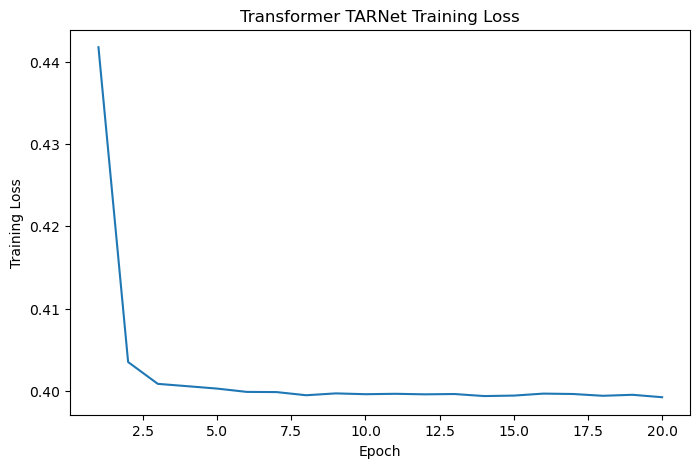

In [61]:
# ============================================
# Unit 13: Plot training loss
# ============================================
plt.figure(figsize=(8, 5))
plt.plot(range(1,number_of_epochs+1),train_losses,)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Transformer TARNet Training Loss")

plt.show()

In [62]:
# ============================================
# Unit 14: Generate test predictions
# ============================================
model.eval()

all_control_probabilities = []
all_treatment_probabilities = []

with torch.no_grad():
    for (num_batch,cat_batch,treatment_batch,outcome_batch,) in test_loader:

        num_batch = num_batch.to(device)
        cat_batch = cat_batch.to(device)

        control_logits,treatment_logits=model(num_batch,cat_batch,)
        control_probabilities = torch.sigmoid(control_logits)
        treatment_probabilities = torch.sigmoid(treatment_logits)
        all_control_probabilities.append(control_probabilities.cpu())
        all_treatment_probabilities.append(treatment_probabilities.cpu())

In [63]:
control_probability_test = torch.cat(all_control_probabilities,dim=0,)
treatment_probability_test = torch.cat(all_treatment_probabilities,dim=0,)
uplift_test = (treatment_probability_test-control_probability_test)

print("Control prob", control_probability_test.shape)
print("Treatment prob", treatment_probability_test.shape)
print("Uplift", uplift_test.shape)

Control prob torch.Size([12800, 1])
Treatment prob torch.Size([12800, 1])
Uplift torch.Size([12800, 1])


In [64]:
# ============================================
# Unit 15: Inspect predictions
# ============================================

print("Average predicted control prob ",control_probability_test.mean().item(),)
print("Average predicted treatment prob ",treatment_probability_test.mean().item(),)
print("Average predicted uplift",uplift_test.mean().item(),)
print("Minimum predicted uplift",uplift_test.min().item(),)
print("Maximum predicted uplift",uplift_test.max().item(),)

Average predicted control prob  0.10879310965538025
Average predicted treatment prob  0.16072560846805573
Average predicted uplift 0.05193251743912697
Minimum predicted uplift -0.0018695741891860962
Maximum predicted uplift 0.11328335851430893
